# Comparison of errors and dissimilarity measures on simulated data

Cluster LOCO-Split requires choosing a metric of error. Investigate the choice of classifier on 4 canonical simulations with different difficulties. 
1) 3-GMM canonical example (2 signal features, 3 noise features)
2) Non linearly separable toy example (3 signal features, 2 noise feature)
3) 5-GMM with correlated features (Toeplitz correlation with $\rho = 0.2$, 5 signal features, 5 noise features)
4) 5-GMM with correlated features (Toeplitz correlation with $\rho = 0.8$, 5 signal features, 5 noise features)


## On toy example

 All_scanpy_datasets.ipynb      PBMC68K_KMeans7.pkl
 Application_PBMC68k.ipynb      clusterwise_pbmc68k.py
 Applications		        coverage_study
 Benchmark_permutation.ipynb    data_simulations
 CH_Computational_eval.ipynb    full_marker_list_hand.csv
 CH_DR+Clustering.ipynb         get_author_dataset.py
 CH_HigherD_simulations.ipynb   global_cluster_loco
 CH_Scaling_C-LOCO.ipynb        global_results.pkl
 Figure2_cleaned.ipynb	        minipatch_cluster_loco
 Figures3_4_clean.ipynb         minipatch_regression
 HC_K11_PBMC68k.py	        pbmc68k.sh
'Naive GMM-stochastic.ipynb'    pbmc68k_cluster.npy
 PBMC3k_legacy_workflow.ipynb   toy_datasets.py


In [1]:
import sys
sys.path.append('../../')
from simulations.toy_datasets import *
from clim import Cluster_LOCO_Split
from clim.utils.utils import *
from clim.utils.non_conformity_scores import *
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'simulations'

In [4]:
from sklearn.preprocessing import StandardScaler

def generate_non_gaussian(n_samples, seed=0):
    # scales = np.array([0.2615908, 0.4728564, 1.0])
    X, y = make_interlaced_halfmoons_3feat(
        n_per_class=n_samples//3,
        noise_xy=0.07,
        noise_f3=0.1,
        seed=seed,
        f3_mode="nonlinear", # "class_offset", 
        f3_offsets=(0.8, -0.1, 0.35)
    )
    X = StandardScaler().fit_transform(X)
    X_perm = np.random.uniform(low=np.min(X), high=np.max(X), size=(X.shape[0], 2))
    
    X = np.concatenate([X, X_perm], axis=1)
    return X, y

n, seed = 1200, 24
X, y = generate_non_gaussian(n_samples=n, seed=seed)
X = X[:, [1, 0, 2, 3, 4]]

In [5]:
X.shape

(1200, 5)

In [6]:
from clim.split.SplitClusterLOCO import *
from clim.non_conformity_scores import *
from clim.models.sklearn_wrappers import *
from sklearn.preprocessing import StandardScaler
import tqdm
K = 3
model = BaseSpectralClustering(n_clusters=K)
X_tr, X_ca, y_tr, y_ca = train_test_split(X, y, test_size=0.5, shuffle=True)

In [7]:
T = 20
g_ari, g_hinge, g_margin, g_hamming, g_l2 = np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])),  np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1]))
for t in tqdm.tqdm(range(T)):
    new = np.random.randint(0, 100*T)
    print(new)
    g_ari[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=model, clf=RandomForestClassifier(), K=3, seed=new, error_metric='ARI', n_jobs=-1)[0]
    g_hinge[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=model, clf = RandomForestClassifier(), K=3, seed=new, error_metric=None, n_jobs=-1)[0]
    g_margin[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=model, clf = RandomForestClassifier(), K=3, seed=new, error_metric=margin_error, n_jobs=-1)[0]
    g_hamming[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=model, clf = RandomForestClassifier(), K=3, seed=new, error_metric=misclassification_error, use_proba=False, n_jobs=-1)[0]
    g_l2[t,:] =  Cluster_LOCO_Split(X_tr, X_ca, model=model, clf = RandomForestClassifier(), K=3, seed=new, error_metric=l2_error, use_proba=False, n_jobs=-1)[0]

  0%|                                                    | 0/20 [00:00<?, ?it/s]

715
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3


  5%|██▏                                         | 1/20 [00:28<09:08, 28.89s/it]

387
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3


 10%|████▍                                       | 2/20 [00:52<07:48, 26.03s/it]

...

 90%|██████████████████████████████████████▋    | 18/20 [01:53<00:06,  3.06s/it]

1537
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3


 95%|████████████████████████████████████████▊  | 19/20 [01:56<00:03,  3.06s/it]

446
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3
Reset n_clusters to 3


100%|███████████████████████████████████████████| 20/20 [01:59<00:00,  5.98s/it]


In [16]:
reorder = [0, 2, 1, 3, 4]

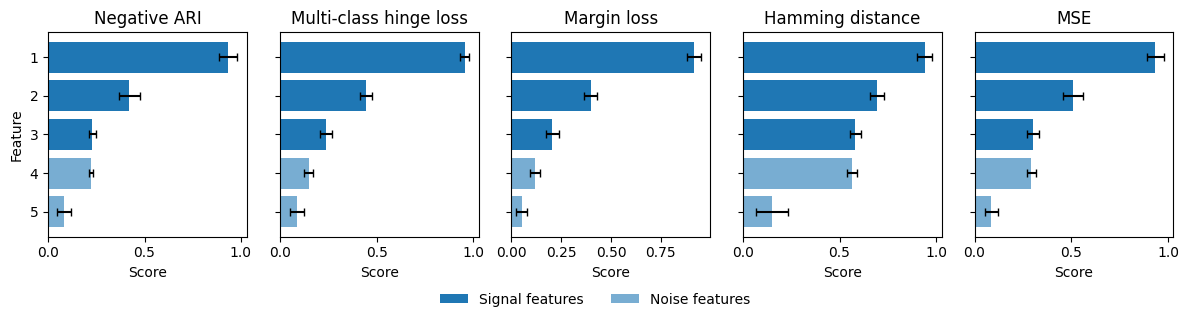

In [19]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 5, figsize=(12, 3), sharey=True)

metrics = [
    (g_ari[:, reorder], "Negative ARI"),
    (g_hinge[:, reorder], "Multi-class hinge loss"),
    (g_margin[:, reorder], "Margin loss"),
    (g_hamming[:, reorder], "Hamming distance"),
    (g_l2[:, reorder], "MSE"),
]

y = np.arange(X.shape[1])

colors = ["tab:blue"] * X.shape[1]
alphas = np.array([1.0, 1.0, 1.0, 0.6, 0.6])

def normalize(x):
    return (x - np.min(x))/(np.max(x)-np.min(x))
for a, (g, title) in zip(ax, metrics):
    g = normalize(g)
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1) #  / np.sqrt(np.sum(~np.isnan(g), axis=0))

    bars = a.barh(y, mean, xerr=se, capsize=3, color=colors)

    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

legend_handles = [
    Patch(facecolor="tab:blue", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:blue", alpha=0.6, label="Noise features"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()

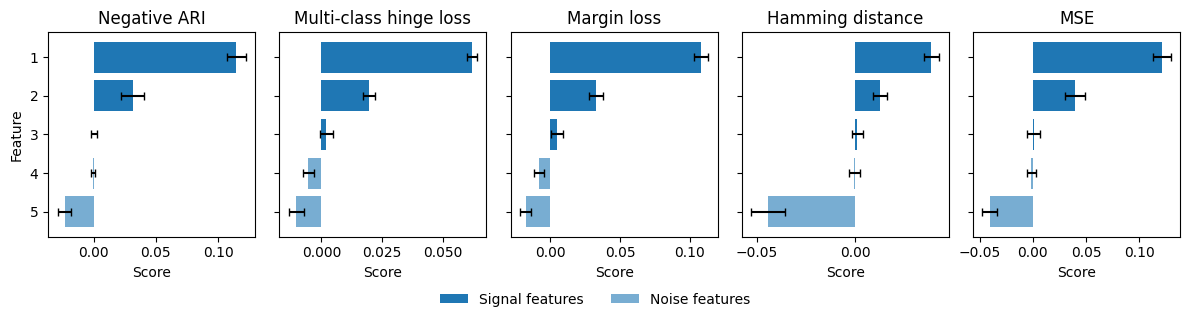

In [20]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 5, figsize=(12, 3), sharey=True)

metrics = [
    (g_ari[:, reorder], "Negative ARI"),
    (g_hinge[:, reorder], "Multi-class hinge loss"),
    (g_margin[:, reorder], "Margin loss"),
    (g_hamming[:, reorder], "Hamming distance"),
    (g_l2[:, reorder], "MSE"),
]

y = np.arange(X.shape[1])

colors = ["tab:blue"] * X.shape[1]
alphas = np.array([1.0, 1.0, 1.0, 0.6, 0.6])


for a, (g, title) in zip(ax, metrics):
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1) #  / np.sqrt(np.sum(~np.isnan(g), axis=0))

    bars = a.barh(y, mean, xerr=se, capsize=3, color=colors)

    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

legend_handles = [
    Patch(facecolor="tab:blue", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:blue", alpha=0.6, label="Noise features"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()

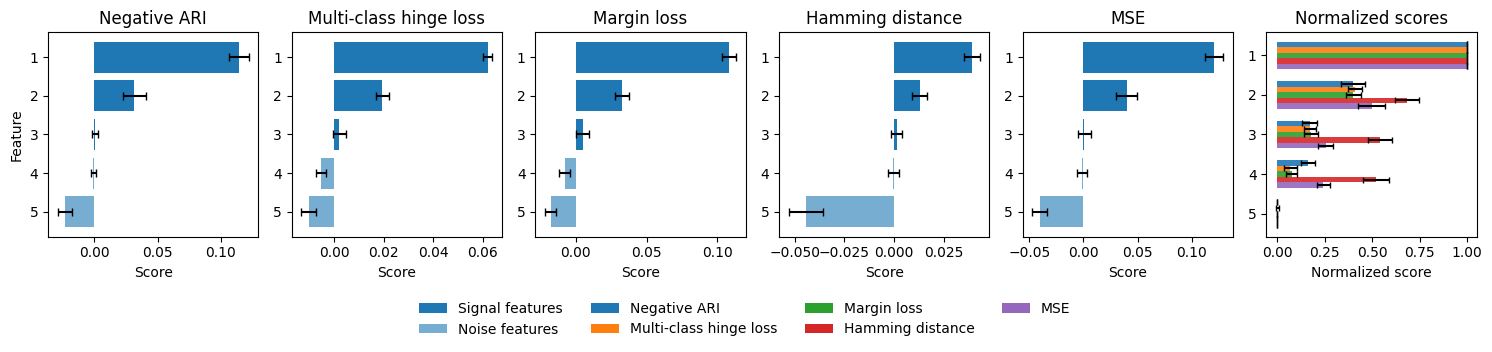

In [22]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 6, figsize=(15, 3), sharey=False)

metrics = [
    (g_ari[:, reorder], "Negative ARI"),
    (g_hinge[:, reorder], "Multi-class hinge loss"),
    (g_margin[:, reorder], "Margin loss"),
    (g_hamming[:, reorder], "Hamming distance"),
    (g_l2[:, reorder], "MSE"),
]

method_colors = {
    "Negative ARI": "tab:blue",
    "Multi-class hinge loss": "tab:orange",
    "Margin loss": "tab:green",
    "Hamming distance": "tab:red",
    "MSE": "tab:purple",
}

y = np.arange(X.shape[1])

feature_colors = ["tab:blue"] * X.shape[1]
feature_alphas = np.array([1.0, 1.0, 1.0, 0.6, 0.6])

# ---- first five panels: raw scores ----
for a, (g, title) in zip(ax[:5], metrics):
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1)

    bars = a.barh(
        y,
        mean,
        xerr=se,
        capsize=3,
        color=feature_colors,
    )

    for bar, alpha in zip(bars, feature_alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

# ---- sixth panel: normalized scores by method ----
norm_means = []
norm_ses = []
method_names = []

for g, title in metrics:
    # normalize each run across features, then average across runs
    g_norm = np.apply_along_axis(normalize, 1, g)

    norm_means.append(np.nanmean(g_norm, axis=0))
    norm_ses.append(np.nanstd(g_norm, axis=0, ddof=1))
    method_names.append(title)

norm_means = np.asarray(norm_means)  # shape: (n_methods, n_features)
norm_ses = np.asarray(norm_ses)

# Put all methods side-by-side for each feature
width = 0.14
offsets = (np.arange(len(metrics)) - (len(metrics) - 1) / 2) * width

for method_idx, title in enumerate(method_names):
    ax[5].barh(
        y + offsets[method_idx],
        norm_means[method_idx],
        xerr=norm_ses[method_idx],
        height=width,
        capsize=2,
        color=method_colors[title],
        alpha=0.9,
        label=title,
    )

ax[5].set_title("Normalized scores")
ax[5].set_xlabel("Normalized score")
ax[5].set_yticks(y)
ax[5].set_yticklabels(np.arange(1, X.shape[1] + 1))
ax[5].invert_yaxis()

# ---- legends ----
feature_legend_handles = [
    Patch(facecolor="tab:blue", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:blue", alpha=0.6, label="Noise features"),
]

method_legend_handles = [
    Patch(facecolor=method_colors[name], label=name)
    for name in method_names
]

fig.legend(
    handles=feature_legend_handles + method_legend_handles,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.18),
    frameon=False,
)

plt.tight_layout()
fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()